In [24]:
import pandas as pd
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [25]:
df.info()
df.describe()
df.isnull().sum()
print("Shape of Dataset:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
Shape of Dataset: (1436, 11)


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

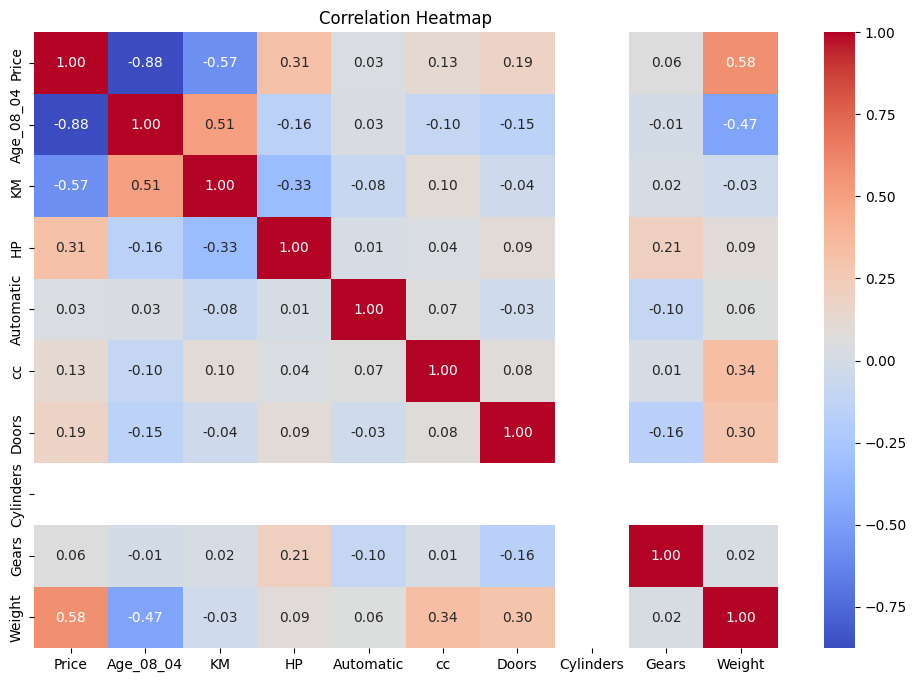

In [27]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

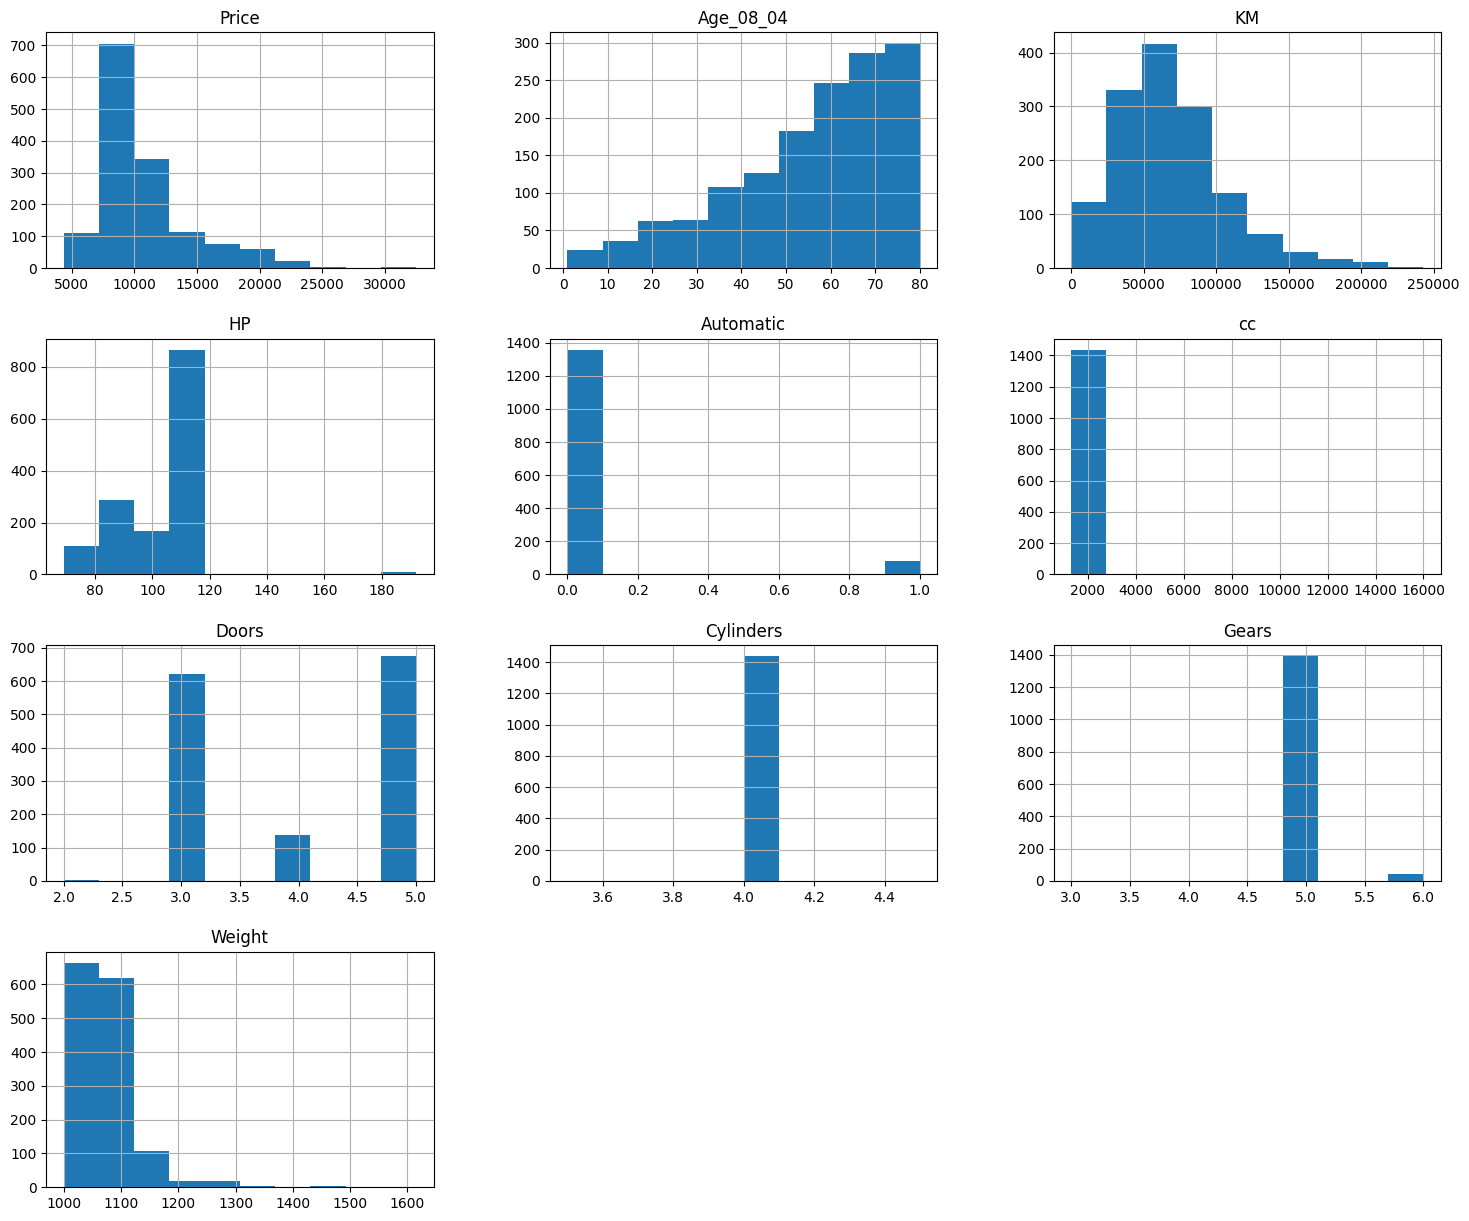

In [28]:
df.hist(figsize=(18,15))
plt.show()

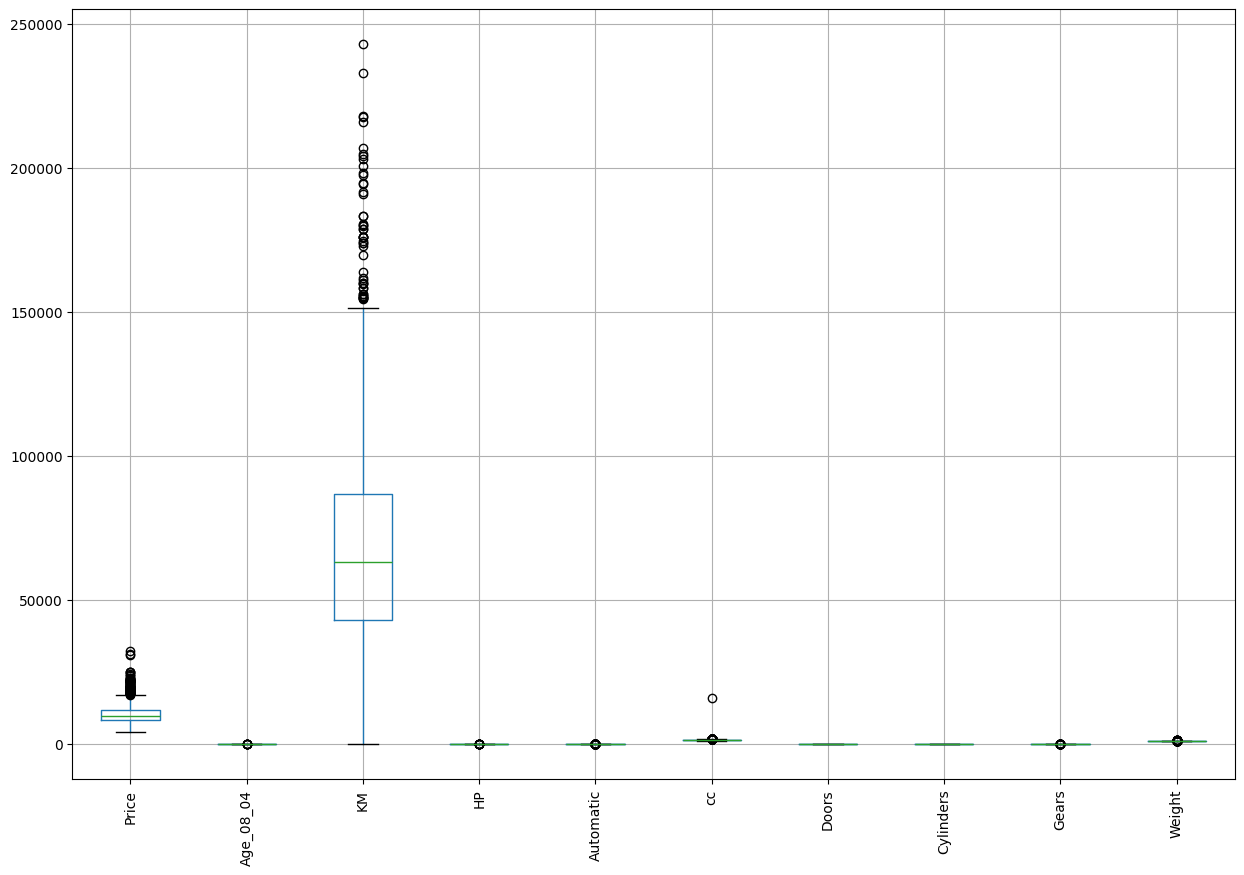

In [29]:
plt.figure(figsize=(15,10))
df.boxplot(rot=90)
plt.show()

In [30]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [31]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1148, 11)
Testing Shape: (288, 11)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1148, 11)
Testing Shape: (288, 11)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [36]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Results")
print("R2 Score :", r2_score(y_test, y_pred1))
print("MAE :", mean_absolute_error(y_test, y_pred1))
print("MSE :", mean_squared_error(y_test, y_pred1))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred1)))

Linear Regression Results
R2 Score : 0.8348888040611081
MAE : 990.8872739193968
MSE : 2203043.8231437043
RMSE : 1484.265415329652


In [38]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

y_pred2 = ridge.predict(X_test_scaled)

In [39]:
print("Ridge Regression Results")
print("R2 Score :", r2_score(y_test, y_pred2))
print("MAE :", mean_absolute_error(y_test, y_pred2))
print("MSE :", mean_squared_error(y_test, y_pred2))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred2)))

Ridge Regression Results
R2 Score : 0.835046263543157
MAE : 990.8591771287421
MSE : 2200942.874523287
RMSE : 1483.5575063081603


In [40]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred3 = lasso.predict(X_test_scaled)

In [41]:
print("Lasso Regression Results")
print("R2 Score :", r2_score(y_test, y_pred3))
print("MAE :", mean_absolute_error(y_test, y_pred3))
print("MSE :", mean_squared_error(y_test, y_pred3))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred3)))

Lasso Regression Results
R2 Score : 0.8349116135580272
MAE : 990.9001968731633
MSE : 2202739.480842682
RMSE : 1484.162888918424


1. Add a Comparison Table Model
| Model | R² Score | MAE | RMSE |
|-------|---------:|----:|------:|
| Linear Regression | 0.8349 | 990.89 | 1484.27 |
| Ridge Regression | 0.8350 | 990.86 | 1483.56 |
| Lasso Regression | 0.8349 | 990.90 | 1484.16 |


What is Normalization and Standardization? How are they helpful?

Answer:

Normalization scales data between 0 and 1.

Standardization transforms data to have mean = 0 and standard deviation = 1.

They help machine learning models perform better by ensuring that features are on a similar scale, improving training speed and model accuracy.

What techniques can be used to address multicollinearity?

Answer:

* Remove highly correlated features.
* Use Ridge Regression.
* Use Lasso Regression.
* Calculate Variance Inflation Factor (VIF).
* Apply Principal Component Analysis (PCA).

## Conclusion

- Performed Exploratory Data Analysis (EDA) on the Toyota Corolla dataset.
- Preprocessed the data by encoding categorical variables and standardizing numerical features.
- Split the data into training and testing datasets.
- Built Multiple Linear Regression, Ridge Regression, and Lasso Regression models.
- Evaluated all models using R² Score, MAE, MSE, and RMSE.
- Ridge and Lasso Regression produced performance comparable to Linear Regression while helping reduce overfitting and multicollinearity.
- The models successfully predicted the price of Toyota Corolla cars based on the given features.